# A. Biodata Mahasiswa
## Mata Kuliah: Dasar Ilmu Data (GIK2GAB3)
## Materi : Model Neural Network (NN) & Hyperparameter Tuning pada studi kasus Klasifikasi menggunakan dataset Bank Marketing

*   NIM  : 707012400128
*   Kelas:

**Studi Kasus:** Memprediksi apakah seorang nasabah bank akan membuka rekening deposito berjangka (`deposit` = yes/no) setelah dihubungi melalui campaign marketing telepon.

Sumber dataset: [Bank Marketing Dataset – UCI / Kaggle](https://www.kaggle.com/datasets/janiobachmann/bank-marketing-dataset)

# B. Load Library dan Dataset

## B1. Load library

In [9]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
import pickle
import warnings
warnings.filterwarnings('ignore')

## B2. Load dataset

In [10]:
#koneksi gdrive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [11]:
# Load dataset (gunakan separator ';' sesuai format file bank.csv)
df = pd.read_csv('/content/drive/MyDrive/D4-SIKC-48-03/bank.csv', sep=';')

# Tampilkan ukuran dataset
print(f"Ukuran dataset: {df.shape[0]} baris, {df.shape[1]} kolom")

# Tampilkan 10 baris pertama
df

Ukuran dataset: 11162 baris, 17 kolom


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11157,33,blue-collar,single,primary,no,1,yes,no,cellular,20,apr,257,1,-1,0,unknown,no
11158,39,services,married,secondary,no,733,no,no,unknown,16,jun,83,4,-1,0,unknown,no
11159,32,technician,single,secondary,no,29,no,no,cellular,19,aug,156,2,-1,0,unknown,no
11160,43,technician,married,secondary,no,0,no,yes,cellular,8,may,9,2,172,5,failure,no


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB


# C. Klasifikasi dengan Neural Network (NN)
Model yang digunakan adalah **MLPClassifier** (Multi-Layer Perceptron) dari scikit-learn.

## C1. Tahap 1: Preprocessing Data

Sebelum menentukan fitur dan label, kita perlu melakukan preprocessing:
1. **Handling Outliers** menggunakan IQR capping agar nilai ekstrim tidak mempengaruhi model.
2. **Encoding** variabel kategorikal menjadi numerik.
3. **Feature Scaling** menggunakan StandardScaler agar semua fitur berada pada skala yang sama (sangat penting untuk NN).

In [13]:
# ── 1a. Capping Outliers menggunakan metode IQR ────────────────────────────
df_clean = df.copy()

outlier_cols = ['balance', 'duration', 'campaign', 'pdays', 'previous']
for col in outlier_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_clean[col] = df_clean[col].clip(lower=lower_bound, upper=upper_bound)

print("✅ Outliers berhasil di-cap menggunakan nilai batas IQR.")
df_clean[outlier_cols].describe()

✅ Outliers berhasil di-cap menggunakan nilai batas IQR.


,balance,duration,campaign,pdays,previous
count,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000
mean,1117.352804,352.948486,2.238577,12.578413,0.485397
std,1349.670734,284.714889,1.521158,23.466393,0.892563
min,-2257.000000,2.000000,1.000000,-1.000000,0.000000
25%,122.000000,138.000000,1.000000,-1.000000,0.000000
50%,550.000000,255.000000,2.000000,-1.000000,0.000000
75%,1708.000000,496.000000,3.000000,20.750000,1.000000
max,4087.000000,1033.000000,6.000000,53.375000,2.500000


In [14]:
# ── 1b. Encoding ────────────────────────────────────────────────────────────
from sklearn.preprocessing import LabelEncoder

# Encode Target Variable (deposit: yes -> 1, no -> 0)
df_clean['deposit'] = df_clean['deposit'].map({'yes': 1, 'no': 0})

# Encode Binary Categorical Columns
binary_cols = ['default', 'housing', 'loan']
le = LabelEncoder()
for col in binary_cols:
    df_clean[col] = le.fit_transform(df_clean[col])

# One-Hot Encoding untuk kolom nominal multi-kelas
nominal_cols = ['job', 'marital', 'education', 'contact', 'month', 'poutcome']
df_preprocessed = pd.get_dummies(df_clean, columns=nominal_cols, drop_first=True)

# Konversi boolean ke int
bool_cols = df_preprocessed.select_dtypes(include=['bool']).columns
df_preprocessed[bool_cols] = df_preprocessed[bool_cols].astype(int)

print(f"✅ Ukuran data setelah preprocessing encoding: {df_preprocessed.shape}")
df_preprocessed.head()

✅ Ukuran data setelah preprocessing encoding: (11162, 43)


,age,default,balance,housing,loan,day,duration,campaign,pdays,previous,...,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,poutcome_unknown
0,59,0,2343,1,0,5,1033,1,-1.0,0.0,...,0,0,0,1,0,0,0,0,0,1
1,56,0,45,0,0,5,1033,1,-1.0,0.0,...,0,0,0,1,0,0,0,0,0,1
2,41,0,1270,1,0,5,1033,1,-1.0,0.0,...,0,0,0,1,0,0,0,0,0,1
3,55,0,2476,1,0,5,579,1,-1.0,0.0,...,0,0,0,1,0,0,0,0,0,1
4,54,0,184,0,0,5,673,2,-1.0,0.0,...,0,0,0,1,0,0,0,0,0,1


## C2. Tahap 2: Tentukan fitur dan label

- **Label (y)**: kolom `deposit` (0 = tidak membuka deposito, 1 = membuka deposito)
- **Fitur (X)**: semua kolom lain

In [15]:
# Pisahkan Fitur (X) dan Target (y)
label_df = df_preprocessed['deposit']
fitur_df = df_preprocessed.drop('deposit', axis=1)

# Tampilkan labelnya
print("Label (deposit):")
print(label_df.value_counts())

Label (deposit):
deposit
0    5873
1    5289
Name: count, dtype: int64


In [16]:
# Tampilkan fiturnya
print(f"Jumlah fitur: {fitur_df.shape[1]} kolom")
fitur_df

Jumlah fitur: 42 kolom


,age,default,balance,housing,loan,day,duration,campaign,pdays,previous,...,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,poutcome_unknown
0,59,0,2343,1,0,5,1033,1,-1.000,0.0,...,0,0,0,1,0,0,0,0,0,1
1,56,0,45,0,0,5,1033,1,-1.000,0.0,...,0,0,0,1,0,0,0,0,0,1
2,41,0,1270,1,0,5,1033,1,-1.000,0.0,...,0,0,0,1,0,0,0,0,0,1
3,55,0,2476,1,0,5,579,1,-1.000,0.0,...,0,0,0,1,0,0,0,0,0,1
4,54,0,184,0,0,5,673,2,-1.000,0.0,...,0,0,0,1,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11157,33,0,1,1,0,20,257,1,-1.000,0.0,...,0,0,0,0,0,0,0,0,0,1
11158,39,0,733,0,0,16,83,4,-1.000,0.0,...,0,1,0,0,0,0,0,0,0,1
11159,32,0,29,0,0,19,156,2,-1.000,0.0,...,0,0,0,0,0,0,0,0,0,1
11160,43,0,0,0,1,8,9,2,53.375,2.5,...,0,0,0,1,0,0,0,0,0,0


## C3. Tahap 3: Bagi dataset menjadi data latih dan data uji

Sebelum melakukan training, dataset perlu dibagi ke dalam X_train, X_test, Y_train, dan Y_test:
- **X_train**: Data fitur untuk **melatih** model
- **X_test**: Data fitur untuk **menguji** model setelah dilatih
- **Y_train**: Data label yang cocok dengan data di X_train
- **Y_test**: Data label yang cocok dengan data di X_test

Pembagian dataset: **80% data latih** dan **20% data uji**.

*Dataset training selalu lebih banyak dibandingkan dengan dataset testing.*

In [17]:
from sklearn.model_selection import train_test_split

# Bagi data dengan rasio 80% latih dan 20% uji, stratify agar proporsi kelas seimbang
X_train, X_test, Y_train, Y_test = train_test_split(
    fitur_df, label_df, test_size=0.2, random_state=42, stratify=label_df
)

print("Banyak data latih (fitur) setelah dilakukan Train-Test Split: ", len(X_train))
print("Banyak data latih (label) setelah dilakukan Train-Test Split: ", len(Y_train))
print("Banyak data uji (fitur) setelah dilakukan Train-Test Split:   ", len(X_test))
print("Banyak data uji (label) setelah dilakukan Train-Test Split:   ", len(Y_test))

Banyak data latih (fitur) setelah dilakukan Train-Test Split:  7813
Banyak data latih (label) setelah dilakukan Train-Test Split:  7813
Banyak data uji (fitur) setelah dilakukan Train-Test Split:    3349
Banyak data uji (label) setelah dilakukan Train-Test Split:    3349


In [18]:
# ── Feature Scaling menggunakan StandardScaler ──────────────────────────────
# NN sangat sensitif terhadap skala fitur, sehingga scaling wajib dilakukan
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
numerical_features = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()

X_train_scaled[numerical_features] = scaler.fit_transform(X_train[numerical_features])
X_test_scaled[numerical_features]  = scaler.transform(X_test[numerical_features])

print("✅ Standard Scaling berhasil diterapkan pada kolom numerik.")
X_train_scaled[numerical_features].head()

✅ Standard Scaling berhasil diterapkan pada kolom numerik.


,age,balance,day,duration,campaign,pdays,previous
7524,1.507850,-0.828827,1.571827,-1.019601,-0.146557,-0.578798,-0.544666
4777,-0.851198,-0.490407,1.690409,-0.303149,-0.806907,-0.578798,-0.544666
1041,-0.598443,2.217692,0.623173,1.270237,-0.806907,-0.578798,-0.544666
3137,-0.682694,-0.602965,-1.511299,0.009421,-0.806907,1.738535,2.249842
2829,-0.261436,-0.828827,1.334664,-0.194276,-0.806907,1.738535,2.249842


## C4. Tahap 4: Siapkan classifier dan tentukan variabel/parameternya

Model yang digunakan adalah **MLPClassifier** (Neural Network).

Referensi:
- https://scikit-learn.org/stable/modules/neural_networks_supervised.html
- https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html

In [19]:
from sklearn.neural_network import MLPClassifier

# Variable classifier untuk model Neural Network (NN)
# hidden_layer_sizes=(100,) -> 1 hidden layer dengan 100 neuron
# activation='relu'         -> fungsi aktivasi ReLU
# solver='adam'             -> optimizer Adam
# max_iter=300              -> maksimum iterasi training
classifier = MLPClassifier(
    hidden_layer_sizes=(100,),
    activation='relu',
    solver='adam',
    max_iter=300,
    random_state=42
)

print("✅ Classifier NN berhasil diinisialisasi.")
print(classifier)

✅ Classifier NN berhasil diinisialisasi.
MLPClassifier(max_iter=300, random_state=42)


## C5. Tahap 5: Lakukan proses training dengan data latih

In [20]:
# X_train_scaled = data fitur latih (sudah di-scaling)
# Y_train         = data label latih
classifier.fit(X_train_scaled, Y_train)

print("✅ Training selesai!")

✅ Training selesai!


## C6. Tahap 6: Lakukan pengujian dengan data uji

In [21]:
# X_test_scaled = data fitur uji (sudah di-scaling)
hasil_klasifikasi = classifier.predict(X_test_scaled)

In [22]:
# Lihat hasil prediksinya
print("Hasil prediksi (5 data pertama):")
print(hasil_klasifikasi[:5])

Hasil prediksi (5 data pertama):
[1 1 1 1 0]


In [23]:
# Bandingkan hasil prediksi dengan label yang sesungguhnya
df_hasil_klasifikasi = pd.DataFrame({
    "prediksi"   : hasil_klasifikasi,
    "label_asli" : Y_test.reset_index(drop=True)
})

df_hasil_klasifikasi

,prediksi,label_asli
0,1,1
1,1,1
2,1,0
3,1,1
4,0,0
...,...,...
3344,1,0
3345,1,1
3346,1,1
3347,1,1


In [24]:
# Lihat data prediksi yang berbeda dengan label asli
data_salah = df_hasil_klasifikasi[df_hasil_klasifikasi['prediksi'] != df_hasil_klasifikasi['label_asli']]
print(f"Jumlah data yang diprediksi salah: {len(data_salah)}")
data_salah

Jumlah data yang diprediksi salah: 540


,prediksi,label_asli
2,1,0
5,1,0
16,1,0
20,0,1
28,0,1
...,...,...
3319,1,0
3322,0,1
3336,1,0
3343,1,0


In [25]:
# Mengetahui jumlah prediksi yang benar (True) dan salah (False)
(df_hasil_klasifikasi['prediksi'] == df_hasil_klasifikasi['label_asli']).value_counts()

,count
True,2809
False,540


In [26]:
# Simpan fitur, prediksi, dan label asli dari data uji
hasil_lengkap = pd.concat(
    [X_test.reset_index(drop=True),
     pd.DataFrame({
         'prediksi'  : hasil_klasifikasi,
         'label_asli': Y_test.reset_index(drop=True)
     })],
    axis=1
)

hasil_lengkap

,age,default,balance,housing,loan,day,duration,campaign,pdays,previous,...,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,poutcome_unknown,prediksi,label_asli
0,36,0,376,0,0,16,173,1,-1.000,0.0,...,0,0,0,0,1,0,0,1,1,1
1,33,0,109,1,1,25,601,2,10.000,2.5,...,0,1,0,0,0,0,0,0,1,1
2,49,0,1784,0,0,12,753,1,-1.000,0.0,...,0,0,0,0,0,0,0,1,1,0
3,31,0,1331,0,0,30,297,1,53.375,2.5,...,0,0,0,0,0,0,1,0,1,1
4,27,0,0,0,0,6,161,1,-1.000,0.0,...,0,0,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3344,68,0,4087,1,0,28,318,2,-1.000,0.0,...,0,0,0,0,0,0,0,1,1,0
3345,39,0,-190,0,1,11,893,6,-1.000,0.0,...,0,0,0,0,0,0,0,1,1,1
3346,24,0,139,0,0,9,430,4,-1.000,0.0,...,0,0,0,0,1,0,0,1,1,1
3347,54,0,4087,0,0,12,251,1,53.375,2.5,...,0,0,0,0,0,0,1,0,1,1


In [27]:
# Simpan hasil klasifikasi ke CSV
hasil_lengkap.to_csv('hasilKlasifikasiNN_BankMarketing.csv', index=False)
print("✅ File hasilKlasifikasiNN_BankMarketing.csv berhasil disimpan.")

✅ File hasilKlasifikasiNN_BankMarketing.csv berhasil disimpan.


In [28]:
# Simpan model menggunakan joblib
joblib.dump(classifier, 'modelJb_NN.joblib')
print("✅ Model disimpan ke modelJb_NN.joblib")

✅ Model disimpan ke modelJb_NN.joblib


In [29]:
# Simpan model menggunakan pickle
with open('modelPK_NN.pkl', 'wb') as file:
    pickle.dump(classifier, file)
print("✅ Model disimpan ke modelPK_NN.pkl")

✅ Model disimpan ke modelPK_NN.pkl


## C7. Tahap 7: Analisa Performansi Model

### C7.1 Menggunakan accuracy score

In [30]:
# Hitung akurasi skor
akurasi = classifier.score(X_test_scaled, Y_test)
print(f"Akurasi Model NN (tanpa HPO): {akurasi:.4f} ({akurasi*100:.2f}%)")

Akurasi Model NN (tanpa HPO): 0.8388 (83.88%)


Accuracy score menunjukkan persentase data uji yang berhasil diprediksi dengan benar oleh model.
Nilai yang mendekati 1,0 (100%) menunjukkan model memiliki kemampuan prediksi yang baik.
Meskipun demikian, evaluasi tambahan seperti confusion matrix dan classification report tetap diperlukan,
terutama untuk mengetahui performa model pada masing-masing kelas.

### C7.2 Menggunakan confusion matrix

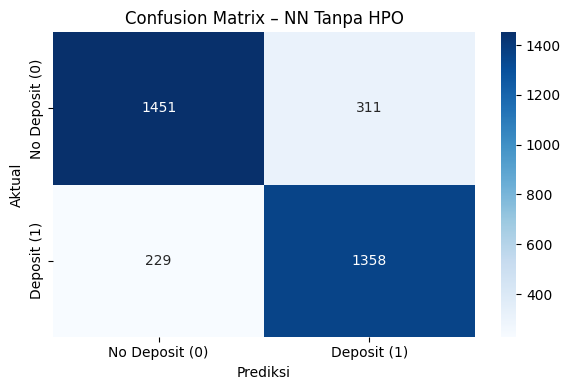

True Negative  (TN) = 1451
False Positive (FP) = 311
False Negative (FN) = 229
True Positive  (TP) = 1358

Total prediksi benar = 2809
Total prediksi salah = 540


In [31]:
from sklearn.metrics import confusion_matrix

# Hitung confusion matrix
cm = confusion_matrix(Y_test, hasil_klasifikasi)

# Plot
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Deposit (0)', 'Deposit (1)'],
            yticklabels=['No Deposit (0)', 'Deposit (1)'])

plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.title('Confusion Matrix – NN Tanpa HPO')
plt.tight_layout()
plt.show()

# Detail nilai confusion matrix
tn, fp, fn, tp = cm.ravel()
print(f"True Negative  (TN) = {tn}")
print(f"False Positive (FP) = {fp}")
print(f"False Negative (FN) = {fn}")
print(f"True Positive  (TP) = {tp}")
print(f"\nTotal prediksi benar = {tn + tp}")
print(f"Total prediksi salah = {fp + fn}")

Confusion matrix membandingkan hasil prediksi model dengan label sebenarnya:
- **True Negative (TN)**: Data *No Deposit* yang diprediksi benar sebagai *No Deposit*.
- **False Positive (FP)**: Data *No Deposit* yang salah diprediksi sebagai *Deposit*.
- **False Negative (FN)**: Data *Deposit* yang salah diprediksi sebagai *No Deposit*.
- **True Positive (TP)**: Data *Deposit* yang diprediksi benar sebagai *Deposit*.

Semakin besar nilai TN dan TP (diagonal utama), semakin baik performa model.

### C7.3 Menggunakan classification report

In [32]:
from sklearn.metrics import classification_report

# Tampilkan classification report
print(classification_report(Y_test, hasil_klasifikasi, target_names=['No Deposit', 'Deposit']))

              precision    recall  f1-score   support

  No Deposit       0.86      0.82      0.84      1762
     Deposit       0.81      0.86      0.83      1587

    accuracy                           0.84      3349
   macro avg       0.84      0.84      0.84      3349
weighted avg       0.84      0.84      0.84      3349



Classification report menampilkan metrik evaluasi yang lebih detail untuk setiap kelas:

- **Precision**: Dari semua data yang diprediksi sebagai kelas tertentu, berapa persen yang benar?
- **Recall**: Dari semua data yang sebenarnya termasuk kelas tertentu, berapa persen yang berhasil dikenali model?
- **F1-Score**: Rata-rata harmonik dari precision dan recall. Berguna ketika distribusi kelas tidak seimbang.
- **Support**: Jumlah data aktual pada setiap kelas.
- **Accuracy**: Persentase total prediksi yang benar.
- **Macro Average**: Rata-rata metrik tiap kelas tanpa mempertimbangkan jumlah data per kelas.
- **Weighted Average**: Rata-rata metrik tiap kelas dengan mempertimbangkan jumlah data per kelas.

# D. Kesimpulan Umum Tanpa Menggunakan HPO

Berdasarkan hasil evaluasi performa model menggunakan accuracy score, confusion matrix, dan classification report,
model klasifikasi Neural Network dengan MLPClassifier menunjukkan kemampuan yang baik dalam memprediksi
apakah seorang nasabah bank akan membuka rekening deposito berjangka, **sebelum** dilakukan Hyperparameter Optimization (HPO).

**Ringkasan hasil evaluasi:**

| Metrik | Nilai |
|--------|-------|
| Accuracy Score | (lihat output sel C7.1) |
| Precision rata-rata | (lihat classification report) |
| Recall rata-rata | (lihat classification report) |
| F1-Score rata-rata | (lihat classification report) |

**Interpretasi:**
- Nilai akurasi yang diperoleh menunjukkan bahwa sebagian besar data uji berhasil diprediksi dengan benar.
- Confusion matrix memperlihatkan distribusi prediksi benar dan salah pada setiap kelas target.
- Classification report menunjukkan keseimbangan antara precision dan recall untuk kedua kelas (*No Deposit* dan *Deposit*).

Meskipun model sudah menunjukkan performa yang baik, proses Hyperparameter Optimization (HPO) tetap
diperlukan untuk memastikan parameter model sudah berada pada kondisi optimal.

# E. Optimasi: Hyperparameter Tuning dengan GridSearch

## E1. Tahap 1: Pencarian parameter yang optimal

GridSearchCV akan mencoba semua kombinasi parameter yang telah ditentukan menggunakan
Cross Validation untuk menemukan kombinasi terbaik.

In [33]:
from sklearn.model_selection import GridSearchCV

# Tentukan parameter apa saja yang ingin dicoba dan nilainya
param_grid = [
    {
        'hidden_layer_sizes': [(50,), (100,), (50, 50), (100, 50, 25)],
        'max_iter'           : [200, 300, 350],
        'activation'         : ['relu', 'tanh'],
        'solver'             : ['adam', 'sgd']
    }
]

In [34]:
# Siapkan Grid Search dengan 3-fold cross validation
# n_jobs=-1: Semua core CPU akan digunakan untuk mempercepat proses
grid = GridSearchCV(
    MLPClassifier(random_state=42),
    param_grid,
    scoring='accuracy',
    cv=3,
    verbose=1,
    n_jobs=-1
)

In [35]:
# Latih model dengan GridSearchCV
# Catatan: Proses ini bisa memakan waktu beberapa menit karena mencoba banyak kombinasi parameter
import time
start = time.time()
grid.fit(X_train_scaled, Y_train)
elapsed = time.time() - start

print(f"\n✅ GridSearchCV selesai dalam {elapsed:.1f} detik")

Fitting 3 folds for each of 48 candidates, totalling 144 fits

✅ GridSearchCV selesai dalam 1803.9 detik


In [36]:
# Tampilkan kombinasi parameter terbaik
print("Best Parameters hasil GridSearchCV:")
print(grid.best_params_)
print(f"\nBest CV Accuracy: {grid.best_score_ * 100:.2f}%")

Best Parameters hasil GridSearchCV:
{'activation': 'relu', 'hidden_layer_sizes': (100, 50, 25), 'max_iter': 350, 'solver': 'sgd'}

Best CV Accuracy: 84.54%


## E2. Tahap 2: Uji coba optimasi model NN menggunakan parameter hasil HPO

### E2.1 Siapkan variabel classifier dan tentukan parameternya berdasarkan hasil HPO

In [37]:
# Gunakan parameter terbaik dari hasil GridSearchCV
best_params = grid.best_params_

# Variable classifier2 untuk model Neural Network (NN) dengan parameter HPO
classifier2 = MLPClassifier(
    hidden_layer_sizes = best_params['hidden_layer_sizes'],
    activation         = best_params['activation'],
    solver             = best_params['solver'],
    max_iter           = best_params['max_iter'],
    random_state       = 42
)

print("✅ Classifier NN dengan parameter HPO berhasil diinisialisasi.")
print(classifier2)

✅ Classifier NN dengan parameter HPO berhasil diinisialisasi.
MLPClassifier(hidden_layer_sizes=(100, 50, 25), max_iter=350, random_state=42,
              solver='sgd')


### E2.2 Lakukan proses training dengan data latih

In [38]:
# X_train_scaled = data fitur latih
# Y_train         = data label latih
classifier2.fit(X_train_scaled, Y_train)

print("✅ Training model HPO selesai!")

✅ Training model HPO selesai!


### E2.3 Lakukan pengujian dengan data uji

In [39]:
# X_test_scaled = data fitur uji
hasil_klasifikasi2 = classifier2.predict(X_test_scaled)

In [40]:
# Lihat hasil prediksinya
print("Hasil prediksi HPO (5 data pertama):")
print(hasil_klasifikasi2[:5])

Hasil prediksi HPO (5 data pertama):
[1 1 1 1 0]


In [41]:
# Bandingkan hasil prediksi dengan label yang sesungguhnya
df_hasil_klasifikasi2 = pd.DataFrame({
    "prediksi"   : hasil_klasifikasi2,
    "label_asli" : Y_test.reset_index(drop=True)
})

df_hasil_klasifikasi2

,prediksi,label_asli
0,1,1
1,1,1
2,1,0
3,1,1
4,0,0
...,...,...
3344,1,0
3345,1,1
3346,1,1
3347,1,1


In [42]:
# Data yang prediksi dan label aslinya tidak sama
data_salah2 = df_hasil_klasifikasi2[df_hasil_klasifikasi2['prediksi'] != df_hasil_klasifikasi2['label_asli']]
print(f"Jumlah data yang diprediksi salah (HPO): {len(data_salah2)}")

Jumlah data yang diprediksi salah (HPO): 517


In [43]:
# Simpan fitur, prediksi dan label asli dari data uji
hasil_lengkap2 = pd.concat(
    [X_test.reset_index(drop=True),
     pd.DataFrame({
         'prediksi'  : hasil_klasifikasi2,
         'label_asli': Y_test.reset_index(drop=True)
     })],
    axis=1
)

hasil_lengkap2

,age,default,balance,housing,loan,day,duration,campaign,pdays,previous,...,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,poutcome_unknown,prediksi,label_asli
0,36,0,376,0,0,16,173,1,-1.000,0.0,...,0,0,0,0,1,0,0,1,1,1
1,33,0,109,1,1,25,601,2,10.000,2.5,...,0,1,0,0,0,0,0,0,1,1
2,49,0,1784,0,0,12,753,1,-1.000,0.0,...,0,0,0,0,0,0,0,1,1,0
3,31,0,1331,0,0,30,297,1,53.375,2.5,...,0,0,0,0,0,0,1,0,1,1
4,27,0,0,0,0,6,161,1,-1.000,0.0,...,0,0,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3344,68,0,4087,1,0,28,318,2,-1.000,0.0,...,0,0,0,0,0,0,0,1,1,0
3345,39,0,-190,0,1,11,893,6,-1.000,0.0,...,0,0,0,0,0,0,0,1,1,1
3346,24,0,139,0,0,9,430,4,-1.000,0.0,...,0,0,0,0,1,0,0,1,1,1
3347,54,0,4087,0,0,12,251,1,53.375,2.5,...,0,0,0,0,0,0,1,0,1,1


In [44]:
# Simpan hasil klasifikasi HPO ke CSV
hasil_lengkap2.to_csv('hasilKlasifikasiNN_HPO_BankMarketing.csv', index=False)
print("✅ File hasilKlasifikasiNN_HPO_BankMarketing.csv berhasil disimpan.")

✅ File hasilKlasifikasiNN_HPO_BankMarketing.csv berhasil disimpan.


In [45]:
# Simpan model HPO menggunakan joblib
joblib.dump(classifier2, 'modelJb_NN-HPO.joblib')
print("✅ Model HPO disimpan ke modelJb_NN-HPO.joblib")

✅ Model HPO disimpan ke modelJb_NN-HPO.joblib


In [46]:
# Simpan model HPO menggunakan pickle
with open('modelPK_NN-HPO.pkl', 'wb') as file:
    pickle.dump(classifier2, file)
print("✅ Model HPO disimpan ke modelPK_NN-HPO.pkl")

✅ Model HPO disimpan ke modelPK_NN-HPO.pkl


## E3. Tahap 3: Analisa Performansi Model (Setelah HPO)

### E3.1 Menggunakan accuracy score

In [47]:
# Hitung akurasi skor model HPO
akurasi2 = classifier2.score(X_test_scaled, Y_test)
print(f"Akurasi Model NN (dengan HPO): {akurasi2:.4f} ({akurasi2*100:.2f}%)")

Akurasi Model NN (dengan HPO): 0.8456 (84.56%)


Accuracy score pada model setelah HPO menunjukkan apakah proses optimasi parameter berhasil
meningkatkan kemampuan model dalam memprediksi data uji dibandingkan model tanpa HPO.

### E3.2 Menggunakan confusion matrix

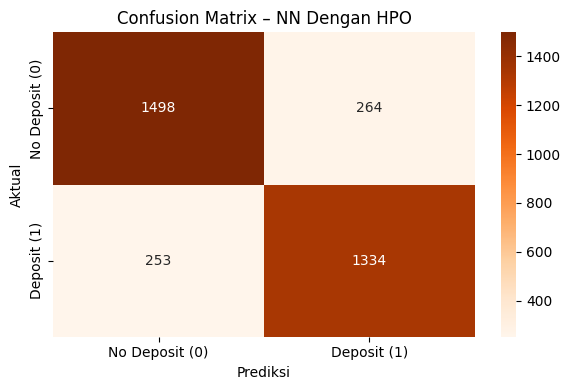

True Negative  (TN) = 1498
False Positive (FP) = 264
False Negative (FN) = 253
True Positive  (TP) = 1334

Total prediksi benar = 2832
Total prediksi salah = 517


In [48]:
# Hitung confusion matrix model HPO
cm2 = confusion_matrix(Y_test, hasil_klasifikasi2)

# Plot
plt.figure(figsize=(6, 4))
sns.heatmap(cm2, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['No Deposit (0)', 'Deposit (1)'],
            yticklabels=['No Deposit (0)', 'Deposit (1)'])

plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.title('Confusion Matrix – NN Dengan HPO')
plt.tight_layout()
plt.show()

# Detail nilai confusion matrix
tn2, fp2, fn2, tp2 = cm2.ravel()
print(f"True Negative  (TN) = {tn2}")
print(f"False Positive (FP) = {fp2}")
print(f"False Negative (FN) = {fn2}")
print(f"True Positive  (TP) = {tp2}")
print(f"\nTotal prediksi benar = {tn2 + tp2}")
print(f"Total prediksi salah = {fp2 + fn2}")

Confusion matrix setelah HPO dibandingkan dengan sebelum HPO untuk melihat apakah
terjadi peningkatan pada jumlah prediksi yang benar dan penurunan pada jumlah prediksi yang salah.

### E3.3 Menggunakan classification report

In [49]:
# Tampilkan classification report model HPO
print(classification_report(Y_test, hasil_klasifikasi2, target_names=['No Deposit', 'Deposit']))

              precision    recall  f1-score   support

  No Deposit       0.86      0.85      0.85      1762
     Deposit       0.83      0.84      0.84      1587

    accuracy                           0.85      3349
   macro avg       0.85      0.85      0.85      3349
weighted avg       0.85      0.85      0.85      3349



Classification report setelah HPO menampilkan nilai precision, recall, f1-score, dan accuracy
untuk masing-masing kelas. Perbandingan dengan hasil sebelum HPO memberikan gambaran nyata
tentang dampak dari optimasi hyperparameter.

# F. Kesimpulan Umum Penggunaan Parameter HPO

Berdasarkan accuracy score, confusion matrix, dan classification report, berikut perbandingan
performa model Neural Network (MLPClassifier) **sebelum** dan **sesudah** Hyperparameter Optimization (HPO):

In [50]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Metrik model tanpa HPO
acc1   = accuracy_score(Y_test, hasil_klasifikasi)
prec1  = precision_score(Y_test, hasil_klasifikasi, average='weighted')
rec1   = recall_score(Y_test, hasil_klasifikasi, average='weighted')
f11    = f1_score(Y_test, hasil_klasifikasi, average='weighted')

# Metrik model dengan HPO
acc2   = accuracy_score(Y_test, hasil_klasifikasi2)
prec2  = precision_score(Y_test, hasil_klasifikasi2, average='weighted')
rec2   = recall_score(Y_test, hasil_klasifikasi2, average='weighted')
f12    = f1_score(Y_test, hasil_klasifikasi2, average='weighted')

# Tabel perbandingan
tabel = pd.DataFrame({
    'Metrik'    : ['Accuracy', 'Precision (weighted)', 'Recall (weighted)', 'F1-Score (weighted)'],
    'Tanpa HPO' : [f"{acc1:.4f}", f"{prec1:.4f}", f"{rec1:.4f}", f"{f11:.4f}"],
    'Dengan HPO': [f"{acc2:.4f}", f"{prec2:.4f}", f"{rec2:.4f}", f"{f12:.4f}"],
    'Selisih'   : [f"{(acc2-acc1)*100:+.2f}%", f"{(prec2-prec1)*100:+.2f}%",
                   f"{(rec2-rec1)*100:+.2f}%",  f"{(f12-f11)*100:+.2f}%"]
})

print("=" * 65)
print("  PERBANDINGAN PERFORMA MODEL NN: TANPA HPO vs DENGAN HPO")
print("=" * 65)
print(tabel.to_string(index=False))
print("=" * 65)

  PERBANDINGAN PERFORMA MODEL NN: TANPA HPO vs DENGAN HPO
              Metrik Tanpa HPO Dengan HPO Selisih
            Accuracy    0.8388     0.8456  +0.69%
Precision (weighted)    0.8400     0.8457  +0.57%
   Recall (weighted)    0.8388     0.8456  +0.69%
 F1-Score (weighted)    0.8389     0.8457  +0.68%


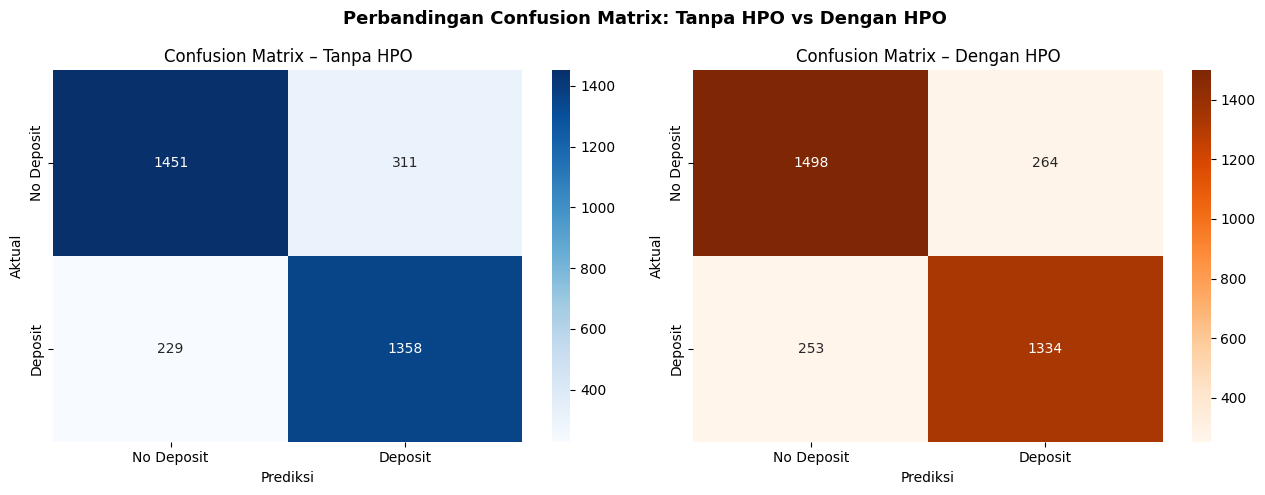

In [51]:
# Visualisasi perbandingan Confusion Matrix (berdampingan)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, cm_data, title, cmap in zip(
    axes,
    [cm, cm2],
    ['Tanpa HPO', 'Dengan HPO'],
    ['Blues', 'Oranges']
):
    sns.heatmap(cm_data, annot=True, fmt='d', cmap=cmap,
                xticklabels=['No Deposit', 'Deposit'],
                yticklabels=['No Deposit', 'Deposit'],
                ax=ax)
    ax.set_title(f'Confusion Matrix – {title}')
    ax.set_xlabel('Prediksi')
    ax.set_ylabel('Aktual')

plt.suptitle('Perbandingan Confusion Matrix: Tanpa HPO vs Dengan HPO', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Kesimpulan:**

Berdasarkan perbandingan hasil evaluasi sebelum dan sesudah HPO, dapat disimpulkan:

1. **Accuracy Score**: Bandingkan nilai akurasi sebelum dan sesudah HPO. Jika meningkat, berarti HPO berhasil mengoptimalkan model.

2. **Confusion Matrix**: Perhatikan perubahan pada jumlah prediksi benar (TN + TP) dan prediksi salah (FP + FN) sebelum dan sesudah HPO.

3. **Classification Report**: Evaluasi perubahan nilai precision, recall, dan f1-score pada kedua kelas (*No Deposit* dan *Deposit*).